In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# Configuración para que los gráficos se vean mejor
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

c:\Users\ggran\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import kagglehub
import os

# Descargar el dataset del Titanic desde Kaggle
path = kagglehub.dataset_download("yasserh/titanic-dataset")
print("Path to dataset files:", path)

# Cargar el archivo Titanic-Dataset.csv
df = pd.read_csv(os.path.join(path, 'Titanic-Dataset.csv'))

df.head(10)


Path to dataset files: C:\Users\ggran\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
df.shape

(891, 12)

In [6]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

Filas: 891, Columnas: 12


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [10]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
df.describe(include='object')

C:\Users\ggran\AppData\Local\Temp\ipykernel_34424\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [12]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [14]:
# Porcentaje de datos faltantes por columna
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent[missing_percent > 0])

Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64


In [15]:
# Eliminar columnas que no aportan al análisis
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Ver cómo quedó el dataset después de eliminar columnas
print("Dataset después de eliminar columnas:")
df.head()

Dataset después de eliminar columnas:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [16]:
# La mediana es más robusta que el promedio ante valores extremos
median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace=True)

# Ver las primeras filas para confirmar que se llenaron los valores faltantes
print(f"Valores de Age imputados con la mediana: {median_age}")
df.head(10)

Valores de Age imputados con la mediana: 28.0


C:\Users\ggran\AppData\Local\Temp\ipykernel_34424\4077525032.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(median_age, inplace=True)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
5,0,3,male,NaN,0,0,8.4583,Q
6,0,1,male,54.0,0,0,51.8625,S
7,0,3,male,2.0,3,1,21.0750,S
8,1,3,female,27.0,0,2,11.1333,S
9,1,2,female,14.0,1,0,30.0708,C


In [17]:
# La moda es el valor más frecuente
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'].fillna(mode_embarked, inplace=True)

# Verificar que se imputaron los valores
print(f"Valores de Embarked imputados con la moda: {mode_embarked}")
df.head(10)

Valores de Embarked imputados con la moda: S


C:\Users\ggran\AppData\Local\Temp\ipykernel_34424\2896098006.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Embarked'].fillna(mode_embarked, inplace=True)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
5,0,3,male,NaN,0,0,8.4583,Q
6,0,1,male,54.0,0,0,51.8625,S
7,0,3,male,2.0,3,1,21.0750,S
8,1,3,female,27.0,0,2,11.1333,S
9,1,2,female,14.0,1,0,30.0708,C


In [19]:
# Si quedan pocos valores faltantes, podemos eliminar esas filas
df = df.dropna()


In [20]:
print(df.isnull().sum())
# Debe mostrar 0 en todas las columnas

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [21]:
# Renombrar para mayor claridad (opcional)
df = df.rename(columns={
    'Pclass': 'Passenger_Class',
    'SibSp': 'Siblings_Spouses',
    'Parch': 'Parents_Children'
})

# Ver los nombres nuevos de las columnas
print("Columnas después de renombrar:")
print(df.columns.tolist())
df.head()

Columnas después de renombrar:
['Survived', 'Passenger_Class', 'Sex', 'Age', 'Siblings_Spouses', 'Parents_Children', 'Fare', 'Embarked']


,Survived,Passenger_Class,Sex,Age,Siblings_Spouses,Parents_Children,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


Survived
0    424
1    288
Name: count, dtype: int64


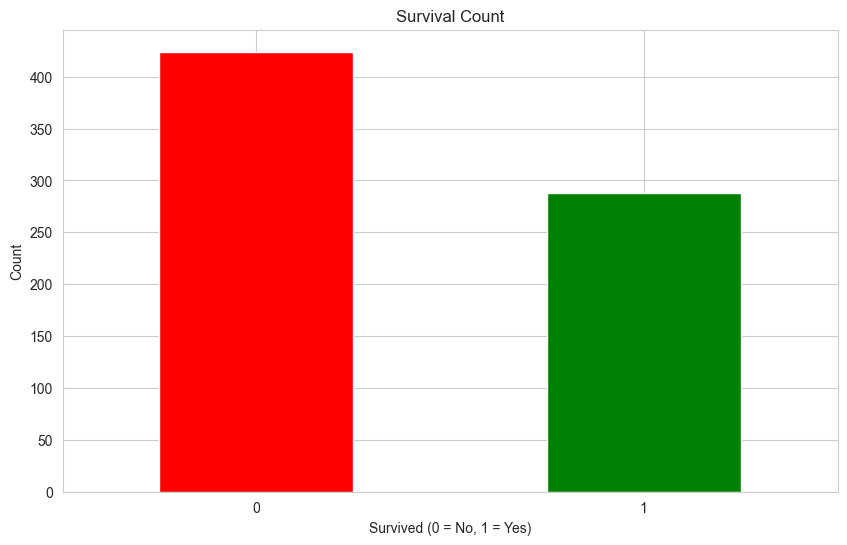

In [22]:
# Contar cuántos sobrevivieron vs murieron
print(df['Survived'].value_counts())

# Visualizar con gráfico de barras
# kind='bar' crea un gráfico de barras vertical
# color=['red', 'green'] asigna rojo a "No sobrevivió" y verde a "Sobrevivió"
df['Survived'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Survival Count')  # Título del gráfico
plt.xlabel('Survived (0 = No, 1 = Yes)')  # Etiqueta del eje X
plt.ylabel('Count')  # Etiqueta del eje Y (cantidad de personas)
plt.xticks(rotation=0)  # Mantener las etiquetas del eje X horizontales
plt.show()

In [48]:
df["Family_Size"] = df["Siblings_Spouses"] + df["Parents_Children"] + 1

df["Is_Alone"] = (df["Family_Size"] == 1).astype(int)

survival_by_alone = df.groupby("Is_Alone")["Survived"].mean() * 100

print("=== SUPERVIVENCIA SEGÚN VIAJABA SOLO O ACOMPAÑADO ===")
print(survival_by_alone)

=== SUPERVIVENCIA SEGÚN VIAJABA SOLO O ACOMPAÑADO ===
Is_Alone
0    51.612903
1    31.840796
Name: Survived, dtype: float64


In [49]:
fare_by_survival = df.groupby("Survived")["Fare"].mean()

print("=== PRECIO MEDIO DEL TICKET ===")
print(fare_by_survival)

=== PRECIO MEDIO DEL TICKET ===
Survived
0    22.965456
1    51.647672
Name: Fare, dtype: float64


In [50]:
df["Age_Group"] = np.where(df["Age"] < 18, "Child", "Adult")

survival_by_age = df.groupby("Age_Group")["Survived"].mean() * 100

print("=== SUPERVIVENCIA POR GRUPO DE EDAD ===")
print(survival_by_age)

=== SUPERVIVENCIA POR GRUPO DE EDAD ===
Age_Group
Adult    37.896494
Child    53.982301
Name: Survived, dtype: float64


Sex
male      453
female    259
Name: count, dtype: int64


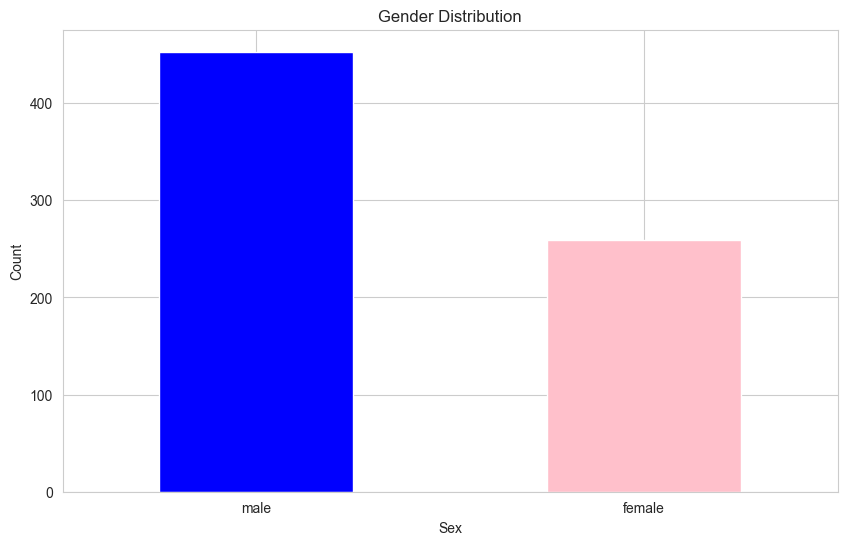

In [24]:
# Contar cuántos hombres y mujeres hay en el dataset
print(df['Sex'].value_counts())

# Visualizar con gráfico de barras
# Mostramos la distribución de género en el Titanic
df['Sex'].value_counts().plot(kind='bar', color=['blue', 'pink'])
plt.title('Gender Distribution')  # Distribución por género
plt.xlabel('Sex')  # Género (male/female)
plt.ylabel('Count')  # Cantidad de personas
plt.xticks(rotation=0)  # Etiquetas horizontales
plt.show()

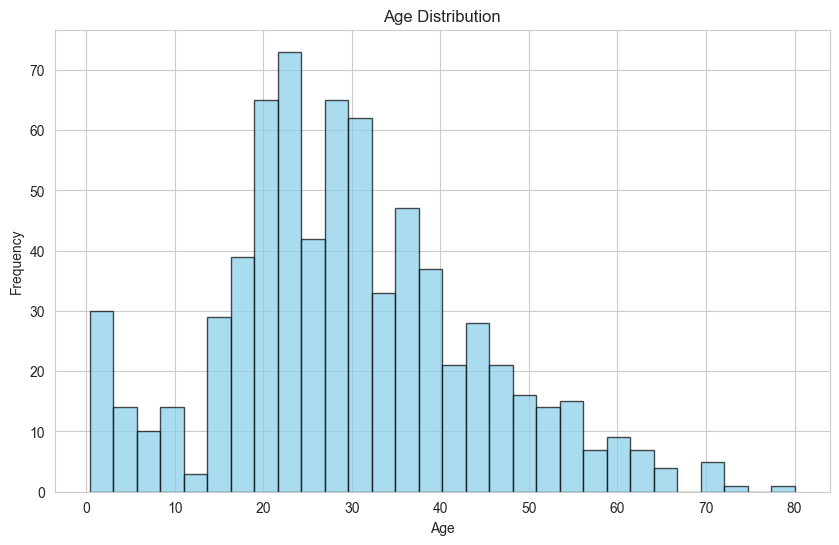

In [25]:
# Histograma para ver la distribución de edades
# bins=30 divide las edades en 30 rangos (ej: 0-3 años, 3-6 años, etc.)
# edgecolor='black' añade un borde negro a cada barra para distinguirlas mejor
# alpha=0.7 hace las barras ligeramente transparentes
df['Age'].plot(kind='hist', bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Age Distribution')  # Distribución de edades
plt.xlabel('Age')  # Edad en años
plt.ylabel('Frequency')  # Frecuencia (cuántas personas)
plt.show()

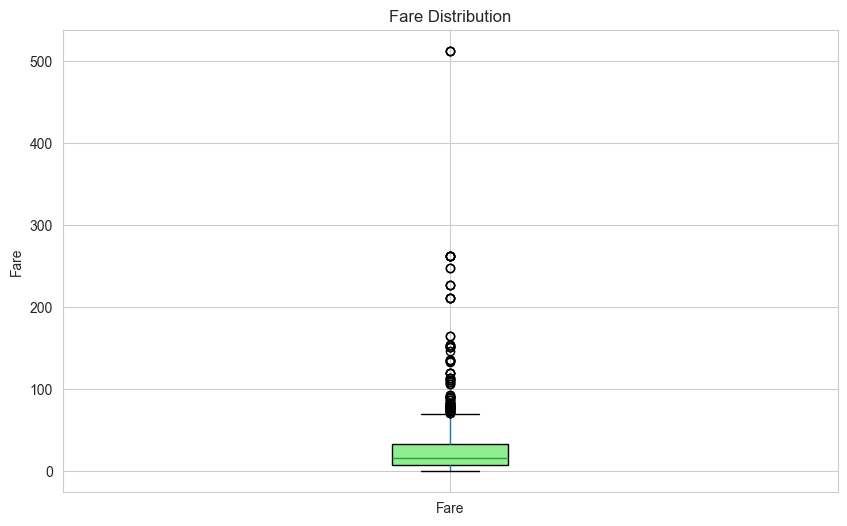

In [26]:
# Boxplot para detectar valores extremos (outliers)
# Un boxplot muestra la distribución de los datos y resalta valores anómalos
df.boxplot(column='Fare', patch_artist=True, 
           boxprops=dict(facecolor='lightgreen'))
plt.title('Fare Distribution')  # Distribución del precio de los tickets
plt.ylabel('Fare')  # Precio del ticket en unidades monetarias
plt.show()

In [27]:
# Tabla cruzada para ver la relación entre sexo y supervivencia
# normalize='index' calcula porcentajes por fila (por cada sexo)
survival_by_sex = pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100
print("Porcentaje de supervivencia por sexo:")
print(survival_by_sex)

Porcentaje de supervivencia por sexo:
Survived          0          1
Sex                           
female    24.710425  75.289575
male      79.470199  20.529801


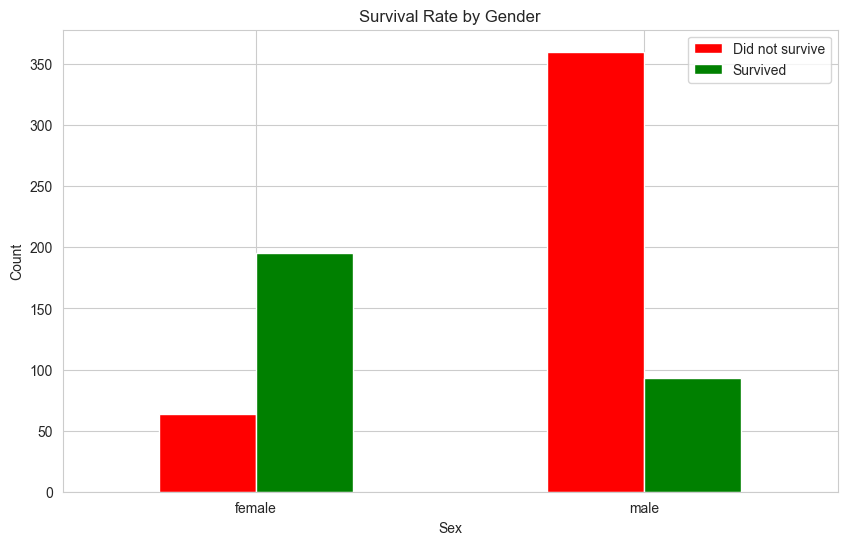

In [28]:
# Gráfico de barras agrupadas para comparar supervivencia por sexo
# Esto nos permite ver visualmente la diferencia entre hombres y mujeres
pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar', color=['red', 'green'])
plt.title('Survival Rate by Gender')  # Tasa de supervivencia por género
plt.xlabel('Sex')  # Género (male/female)
plt.ylabel('Count')  # Cantidad de personas
plt.legend(['Did not survive', 'Survived'])  # Leyenda: rojo=murió, verde=sobrevivió
plt.xticks(rotation=0)  # Mantener etiquetas horizontales
plt.show()

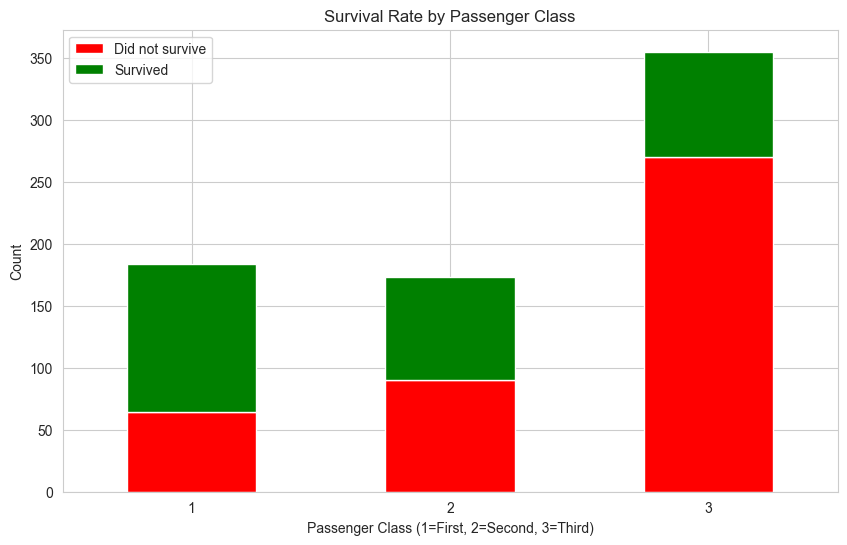

In [29]:
# Análisis de supervivencia por clase de pasajero
# stacked=True apila las barras (muertos + sobrevivientes en la misma columna)
pd.crosstab(df['Passenger_Class'], df['Survived']).plot(kind='bar', stacked=True, 
                                                          color=['red', 'green'])
plt.title('Survival Rate by Passenger Class')  # Supervivencia por clase
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)')  # Clase del ticket
plt.ylabel('Count')  # Cantidad de personas
plt.legend(['Did not survive', 'Survived'])  # Leyenda
plt.xticks(rotation=0)
plt.show()

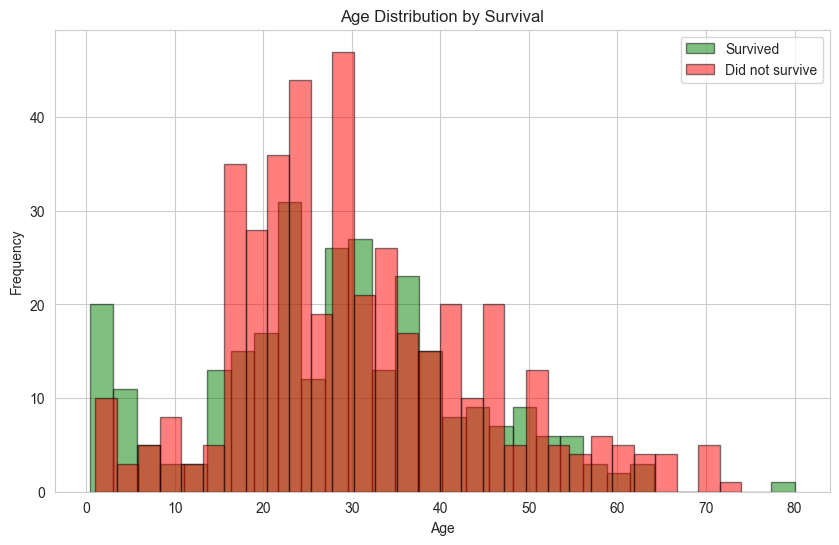

In [30]:
# Distribución de edades por supervivencia
# Comparamos las edades de quienes sobrevivieron vs quienes no
# alpha=0.5 hace los histogramas semi-transparentes para que podamos ver ambos
df[df['Survived']==1]['Age'].plot(kind='hist', bins=30, alpha=0.5, 
                                   label='Survived', color='green', edgecolor='black')
df[df['Survived']==0]['Age'].plot(kind='hist', bins=30, alpha=0.5, 
                                   label='Did not survive', color='red', edgecolor='black')
plt.title('Age Distribution by Survival')  # Distribución de edad según supervivencia
plt.xlabel('Age')  # Edad en años
plt.ylabel('Frequency')  # Frecuencia (cuántas personas)
plt.legend()  # Mostrar leyenda
plt.show()

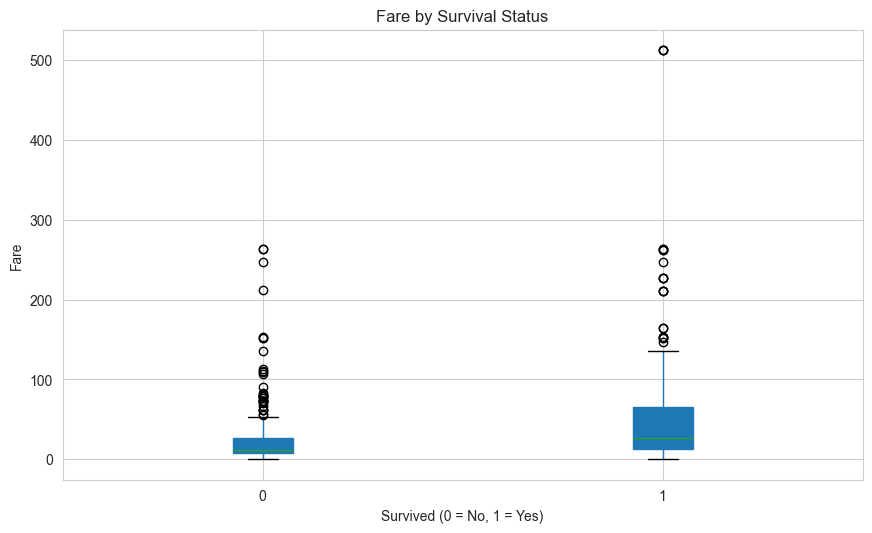

In [31]:
# Boxplot comparativo de precios de tickets por supervivencia
# Comparamos cuánto pagaron los que sobrevivieron vs los que no
df.boxplot(column='Fare', by='Survived', patch_artist=True)
plt.title('Fare by Survival Status')  # Precio del ticket según supervivencia
plt.suptitle('')  # Quitar título automático que genera pandas
plt.xlabel('Survived (0 = No, 1 = Yes)')  # Supervivencia
plt.ylabel('Fare')  # Precio del ticket
plt.show()

In [32]:
# Calcular correlaciones SOLO entre variables numéricas
# select_dtypes(include=[np.number]) selecciona solo columnas con números
# Esto evita errores con columnas de texto como 'Sex' o 'Embarked'
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()
print("Matriz de correlación entre variables numéricas:")
print(correlation)

Matriz de correlación entre variables numéricas:
                  Survived  Passenger_Class       Age  Siblings_Spouses  \
Survived          1.000000        -0.356462 -0.082446         -0.015523   
Passenger_Class  -0.356462         1.000000 -0.365902          0.065187   
Age              -0.082446        -0.365902  1.000000         -0.307351   
Siblings_Spouses -0.015523         0.065187 -0.307351          1.000000   
Parents_Children  0.095265         0.023666 -0.187896          0.383338   
Fare              0.266100        -0.552893  0.093143          0.139860   

                  Parents_Children      Fare  
Survived                  0.095265  0.266100  
Passenger_Class           0.023666 -0.552893  
Age                      -0.187896  0.093143  
Siblings_Spouses          0.383338  0.139860  
Parents_Children          1.000000  0.206624  
Fare                      0.206624  1.000000  


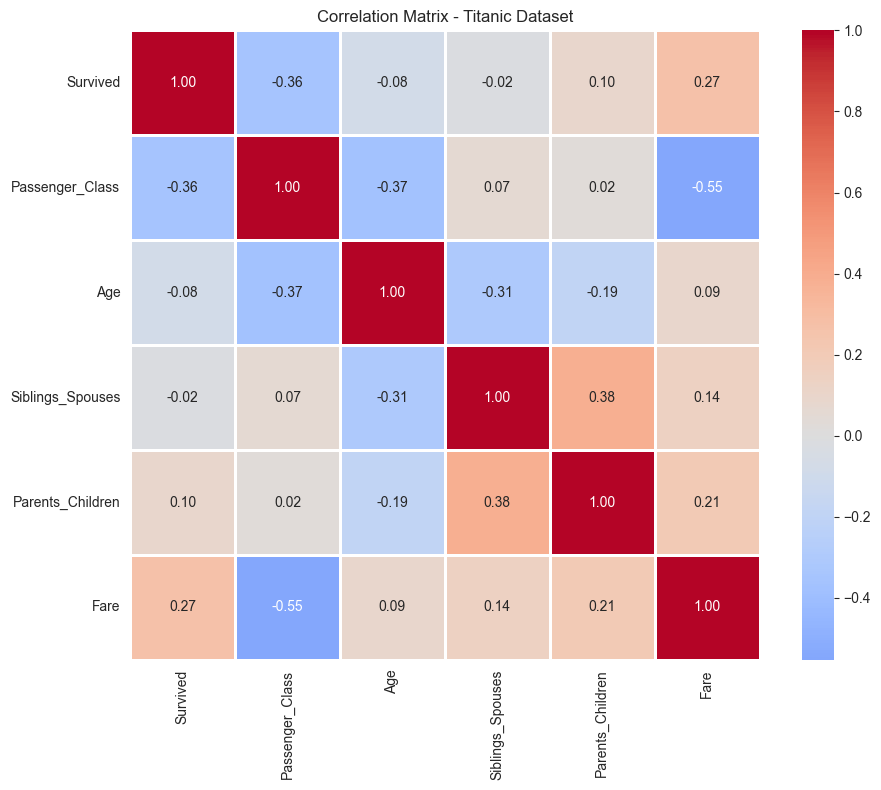

In [33]:
# Crear un heatmap (mapa de calor) para visualizar las correlaciones
plt.figure(figsize=(10, 8))  # Tamaño del gráfico
# annot=True muestra los números dentro de cada celda
# cmap='coolwarm' usa colores: rojo=positivo, azul=negativo
# center=0 centra la escala de colores en cero
# linewidths=1 añade líneas entre celdas para mejor legibilidad
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            linewidths=1, fmt='.2f', square=True)
plt.title('Correlation Matrix - Titanic Dataset')  # Título
plt.tight_layout()  # Ajusta el gráfico para que no se corten las etiquetas
plt.show()

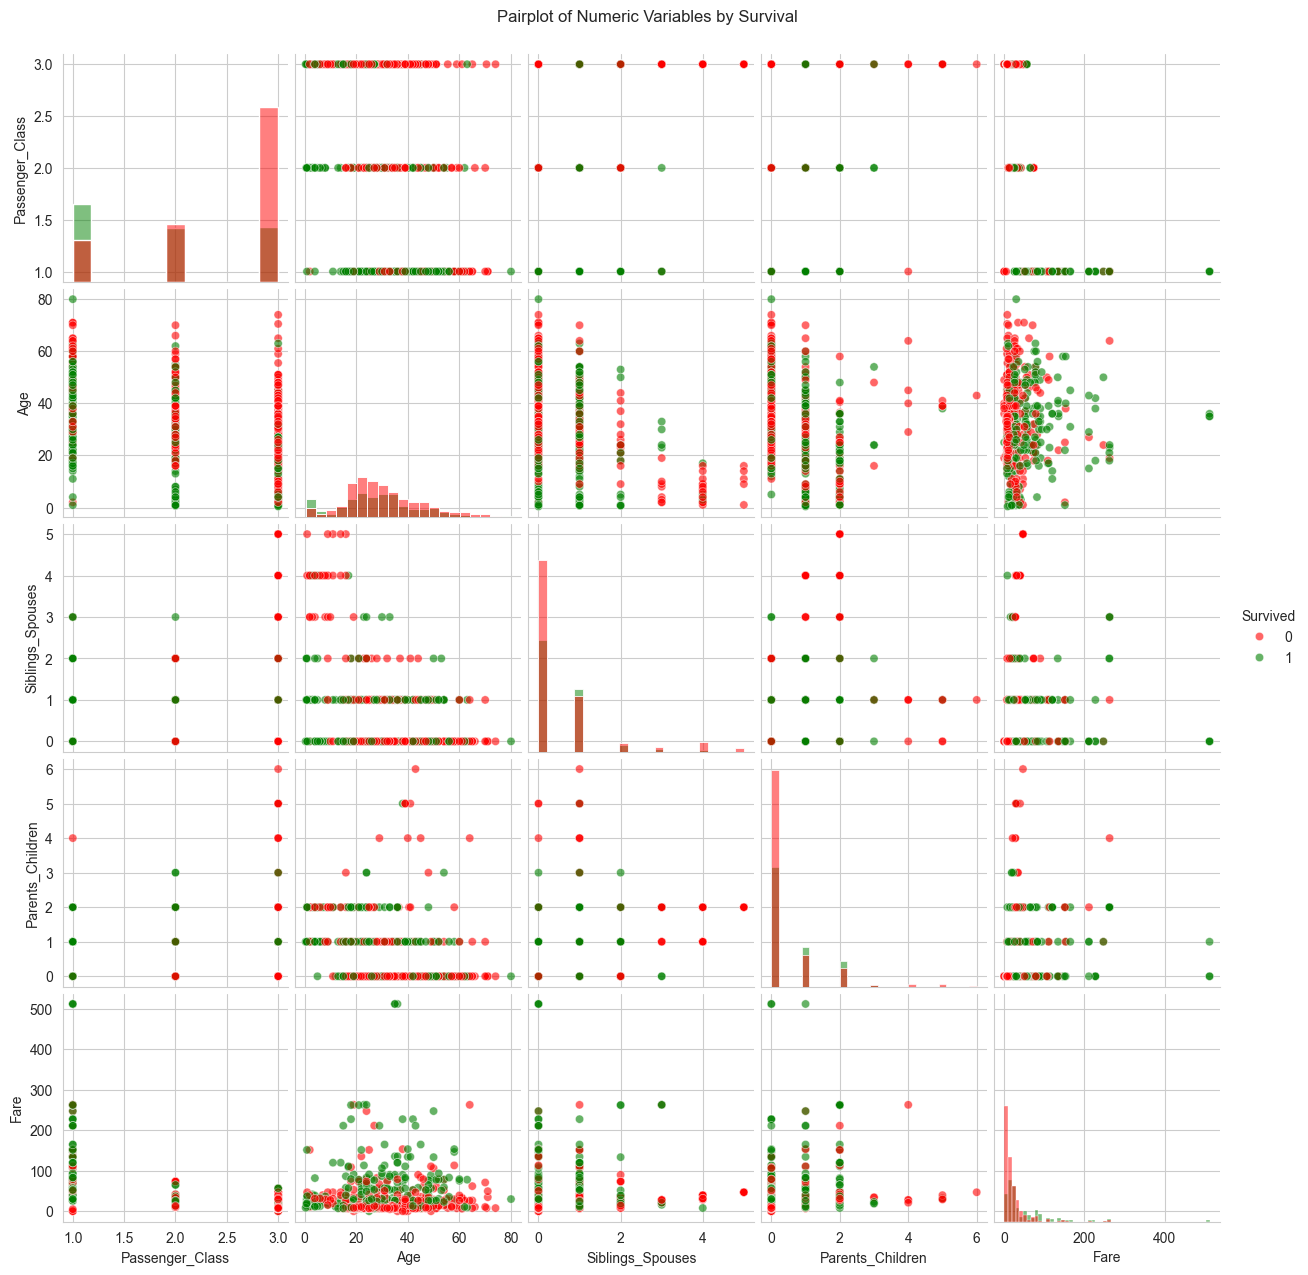

In [35]:
# Visualizar relaciones entre todas las variables numéricas
# hue='Survived' colorea los puntos según si sobrevivieron (verde) o no (rojo)
# palette={0: 'red', 1: 'green'} define los colores específicos
# Este gráfico puede tardar un poco porque crea muchas visualizaciones
sns.pairplot(numeric_df, hue='Survived', palette={0: 'red', 1: 'green'}, 
             diag_kind='hist', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Numeric Variables by Survival', y=1.02)  # Título general
plt.show()

In [36]:
# Sumar hermanos/cónyuges + padres/hijos + 1 (el pasajero mismo)
df['Family_Size'] = df['Siblings_Spouses'] + df['Parents_Children'] + 1

# Ver las nuevas columnas creadas
print("Nueva columna Family_Size creada:")
df[['Siblings_Spouses', 'Parents_Children', 'Family_Size']].head(10)

Nueva columna Family_Size creada:


,Siblings_Spouses,Parents_Children,Family_Size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2
10,1,1,3


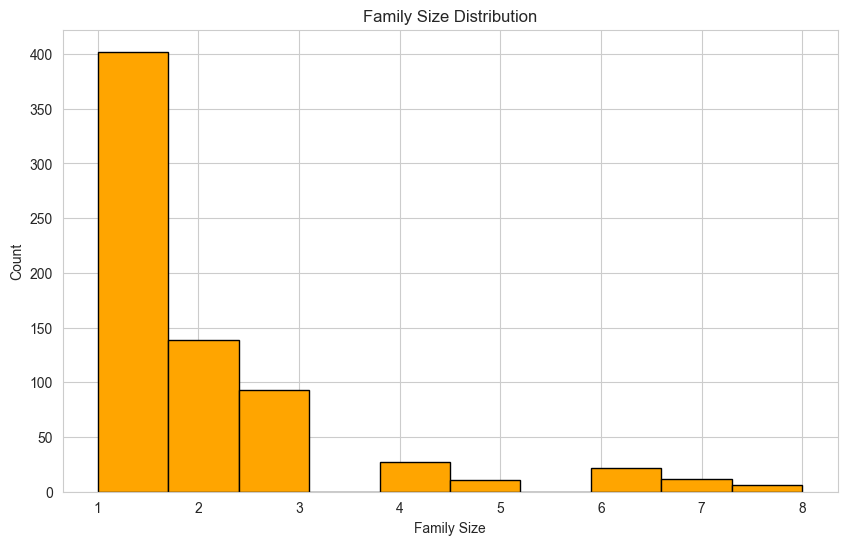

In [37]:
# Visualizar la distribución del tamaño de familia
df['Family_Size'].plot(kind='hist', bins=10, edgecolor='black', color='orange')
plt.title('Family Size Distribution')  # Distribución del tamaño de familia
plt.xlabel('Family Size')  # Tamaño de familia (1=solo, 2+=con familia)
plt.ylabel('Count')  # Cantidad de personas
plt.show()

In [38]:
# Crear variable binaria: 1 si viaja solo, 0 si viaja con familia
df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

# Ver la nueva columna
print("Nueva columna Is_Alone creada:")
df[['Family_Size', 'Is_Alone']].head(10)

Nueva columna Is_Alone creada:


,Family_Size,Is_Alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
6,1,1
7,5,0
8,3,0
9,2,0
10,3,0


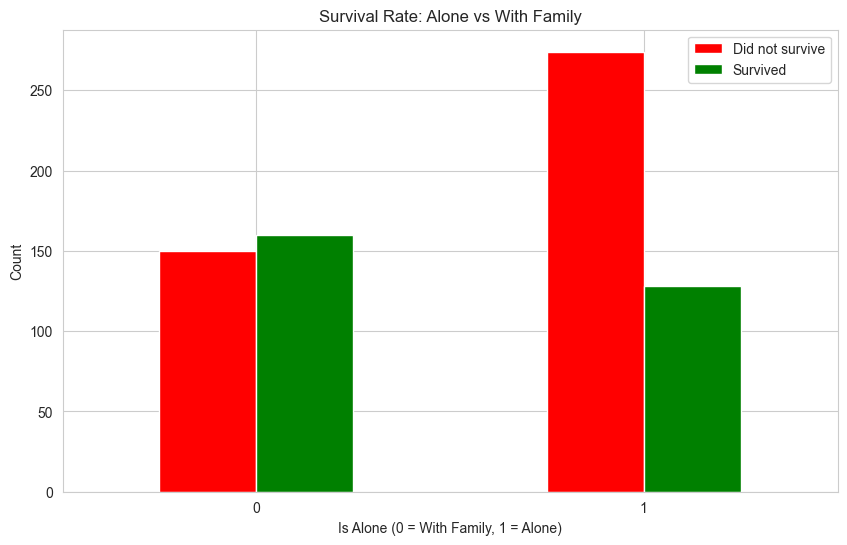

In [39]:
# Analizar supervivencia según si viajaban solos o acompañados
# Esto nos ayuda a responder: ¿viajar solo aumentó o disminuyó las chances de sobrevivir?
pd.crosstab(df['Is_Alone'], df['Survived']).plot(kind='bar', color=['red', 'green'])
plt.title('Survival Rate: Alone vs With Family')  # Supervivencia: solo vs acompañado
plt.xlabel('Is Alone (0 = With Family, 1 = Alone)')  # 0=con familia, 1=solo
plt.ylabel('Count')  # Cantidad de personas
plt.xticks(rotation=0)
plt.legend(['Did not survive', 'Survived'])
plt.show()

In [40]:
# Categorizar edades en grupos significativos
# bins define los límites de cada grupo
# labels define los nombres de cada categoría
df['Age_Group'] = pd.cut(df['Age'], 
                         bins=[0, 12, 18, 35, 60, 100], 
                         labels=['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior'])

# Ver la nueva columna de grupos de edad
print("Nueva columna Age_Group creada:")
df[['Age', 'Age_Group']].head(15)

Nueva columna Age_Group creada:


,Age,Age_Group
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Young Adult
4,35.0,Young Adult
6,54.0,Adult
7,2.0,Child
8,27.0,Young Adult
9,14.0,Teenager
10,4.0,Child


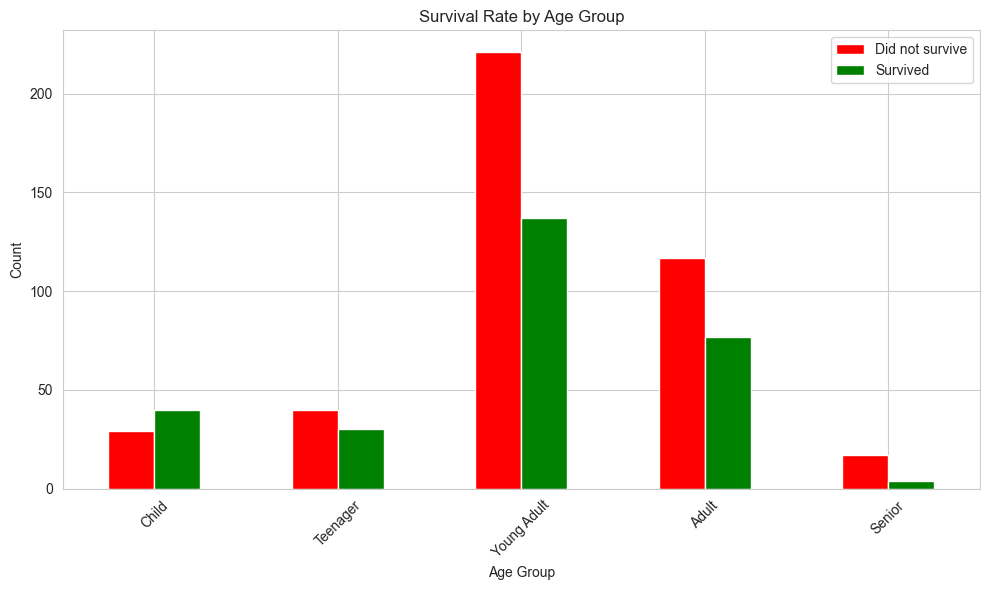

In [41]:
# Analizar supervivencia por grupo de edad
# Esto nos ayuda a ver si "mujeres y niños primero" fue real
pd.crosstab(df['Age_Group'], df['Survived']).plot(kind='bar', color=['red', 'green'])
plt.title('Survival Rate by Age Group')  # Supervivencia por grupo de edad
plt.xlabel('Age Group')  # Grupo de edad
plt.ylabel('Count')  # Cantidad de personas
plt.xticks(rotation=45)  # Rotar etiquetas 45 grados para que no se superpongan
plt.legend(['Did not survive', 'Survived'])
plt.tight_layout()  # Ajustar para que no se corten las etiquetas
plt.show()

In [45]:
# Ejemplo de conclusiones basadas en el análisis

print("=== CONCLUSIONES DEL ANÁLISIS ===\n")

# 1. Tasa de supervivencia general
survival_rate = (df['Survived'].sum() / len(df)) * 100
print(f"1. Tasa de supervivencia general: {survival_rate:.2f}%\n")

# 2. Supervivencia por sexo
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100
print("2. Tasa de supervivencia por sexo:")
print(survival_by_sex)
print()

# 3. Supervivencia por clase
survival_by_class = df.groupby('Passenger_Class')['Survived'].mean() * 100
print("3. Tasa de supervivencia por clase:")
print(survival_by_class)
print()

# 4. Edad promedio de sobrevivientes vs no sobrevivientes
avg_age = df.groupby('Survived')['Age'].mean()
print("4. Edad promedio:")
print(f"   No sobrevivientes: {avg_age[0]:.2f} años")
print(f"   Sobrevivientes: {avg_age[1]:.2f} años")



=== CONCLUSIONES DEL ANÁLISIS ===

1. Tasa de supervivencia general: 40.45%

2. Tasa de supervivencia por sexo:
Sex
female    75.289575
male      20.529801
Name: Survived, dtype: float64

3. Tasa de supervivencia por clase:
Passenger_Class
1    65.217391
2    47.976879
3    23.943662
Name: Survived, dtype: float64

4. Edad promedio:
   No sobrevivientes: 30.63 años
   Sobrevivientes: 28.19 años


In [51]:
print("\n=== CONCLUSIONES COMPLEMENTARIAS ===")

print("\n1. Supervivencia según viajaba solo o acompañado:")
print(survival_by_alone)

print("\n2. Precio medio del ticket:")
print(fare_by_survival)

print("\n3. Supervivencia niños vs adultos:")
print(survival_by_age)


=== CONCLUSIONES COMPLEMENTARIAS ===

1. Supervivencia según viajaba solo o acompañado:
Is_Alone
0    51.612903
1    31.840796
Name: Survived, dtype: float64

2. Precio medio del ticket:
Survived
0    22.965456
1    51.647672
Name: Fare, dtype: float64

3. Supervivencia niños vs adultos:
Age_Group
Adult    37.896494
Child    53.982301
Name: Survived, dtype: float64


# Conclusiones Finales

## 1. ¿Quiénes tuvieron más probabilidad de sobrevivir?

### Sexo

Las mujeres presentaron una tasa de supervivencia del 75.29%, mientras que la de los hombres fue del 20.53%.

Esto indica que el sexo fue uno de los factores más determinantes en la supervivencia de los pasajeros.

### Clase social

Los pasajeros de primera clase tuvieron una tasa de supervivencia del 65.22%, frente al 23.94% de los pasajeros de tercera clase.

La clase social tuvo una influencia significativa en las probabilidades de supervivencia.

### Edad

Los niños presentaron una tasa de supervivencia del 53.98%, superior a la observada en los adultos (37.90%).

Además, la edad promedio de los supervivientes fue de 28.19 años frente a los 30.63 años de los no supervivientes.

---

## 2. ¿Qué factores fueron más importantes?

Los factores que mostraron una mayor relación con la supervivencia fueron:

- Sexo
- Clase social
- Edad

Las mujeres, los pasajeros de clases superiores y los niños presentaron mayores probabilidades de sobrevivir.

---

## 3. ¿Hubo algún patrón interesante?

### Pasajeros solos vs acompañados

Los pasajeros que viajaban acompañados tuvieron una tasa de supervivencia del 51.61%, mientras que aquellos que viajaban solos registraron una tasa del 31.84%.

Esto sugiere que viajar en familia o acompañado pudo aumentar las probabilidades de supervivencia.

### Precio del billete

Los pasajeros supervivientes pagaron un precio medio de 51.65 unidades monetarias, mientras que los no supervivientes pagaron un promedio de 22.97.

Este resultado indica una posible relación entre el precio del billete y la supervivencia, probablemente asociada a la clase social y la ubicación de los pasajeros dentro del barco.

---

## Conclusión general

El análisis exploratorio revela que la supervivencia en el Titanic no fue aleatoria. Variables como el sexo, la clase social, la edad y el tamaño de la familia muestran una relación clara con las probabilidades de supervivencia.

Las mujeres, los niños, los pasajeros de primera clase y aquellos que viajaban acompañados tuvieron mayores probabilidades de sobrevivir al desastre.